In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

2025-11-28 12:19:48.053300: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-28 12:19:48.069533: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 12:19:48.566484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-28 12:19:49.904833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [3]:
from tensorflow.keras.preprocessing.image import load_img

In [4]:
path = "../data/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name,target_size=(299,299))

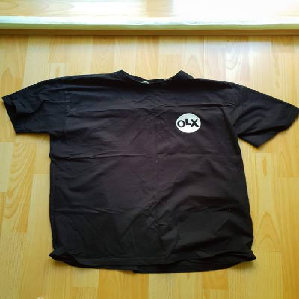

In [5]:
img

In [6]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x786A5AB838C0>


In [7]:
#converting image to array
x = np.array(img)

In [8]:
# 3 channels with RGB
x.shape

(299, 299, 3)

## Pre-trained convolutional neural networks

- Imagenet Dataset: https://www.image-net.org/

- Pre-trained models: https://keras.io/api/applications/

In [9]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [10]:
model = Xception(weights="imagenet",input_shape=(299,299,3))

2025-11-28 12:19:51.151668: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
X = np.array([x])

In [12]:
X.shape

(1, 299, 299, 3)

In [13]:
X = preprocess_input(X)

In [14]:
X[0]

array([[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.41960788,  0.35686278, -0.20784312],
        ...,
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.99215686,  0.9372549 ]],

       [[ 0.47450984,  0.4039216 , -0.12156862],
        [ 0.4666667 ,  0.39607847, -0.12941176],
        [ 0.45882356,  0.38823533, -0.15294117],
        ...,
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.92941177]],

       [[ 0.56078434,  0.48235297, -0.00392157],
        [ 0.5686275 ,  0.4901961 ,  0.00392163],
        [ 0.5686275 ,  0.49803925, -0.01176471],
        ...,
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863]],

       ...,

       [[ 0.2941177 ,  0.18431377, -0.40392154],
        [ 0

In [15]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


In [16]:
pred.shape

(1, 1000)

In [17]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.68196267)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814007)),
  ('n04370456', 'sweatshirt', np.float32(0.03432477)),
  ('n03710637', 'maillot', np.float32(0.011354245)),
  ('n04525038', 'velvet', np.float32(0.0018453626))]]

## Transfer Learning

- Keep the convolutional layers of imagenet because its more generic

- train on the dataset we have this creates new denselayers

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds= train_gen.flow_from_directory("../data/train",target_size=(150,150),batch_size=32)

Found 3068 images belonging to 10 classes.


In [20]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [21]:
X,y = next(train_ds)

In [22]:
X.shape

(32, 150, 150, 3)

In [23]:
y[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [24]:
# for validation

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds= val_gen.flow_from_directory("../data/validation",target_size=  (150,150),batch_size=32,shuffle=False)

Found 341 images belonging to 10 classes.


In [25]:
# training a base model

base_model = Xception(weights='imagenet',include_top=False,input_shape=(150,150,3))

base_model.trainable = False

inputs = keras.Input(shape=(150,150,3))

base = base_model(inputs,training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs,outputs)

In [26]:
# to train model, we need optimiser, we need to change the weights which lead to better solution

learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])

In [27]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 628ms/step - accuracy: 0.6620 - loss: 1.3131 - val_accuracy: 0.7331 - val_loss: 1.1888
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 850ms/step - accuracy: 0.8080 - loss: 0.6108 - val_accuracy: 0.7390 - val_loss: 1.1171
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 919ms/step - accuracy: 0.8660 - loss: 0.3937 - val_accuracy: 0.7947 - val_loss: 0.8341
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 886ms/step - accuracy: 0.9214 - loss: 0.2244 - val_accuracy: 0.7977 - val_loss: 0.8778
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 86s 900ms/step - accuracy: 0.9325 - loss: 0.1811 - val_accuracy: 0.8006 - val_loss: 0.8628
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 773ms/step - accuracy: 0.9566 - loss: 0.1161 - val_accuracy: 0.8123 - val_loss: 0.9637
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 78s 814ms/step - accuracy: 0.9586 - loss: 0.1211 - val_accuracy: 0.7977 - val_loss: 1.0886
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 768ms/step - accuracy: 0.9677 - loss: 0.0882 - val_accu

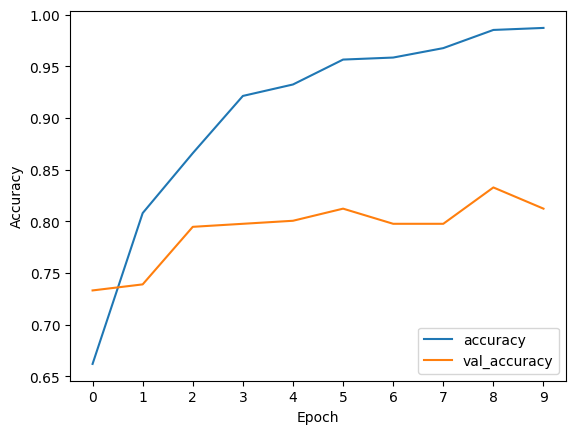

In [28]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(10))
plt.legend(loc='lower right')
plt.show()

# Adjusting the learning rate

In [29]:
def make_model(learning_rate = 0.01):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    ######################################################

    base_model.trainable = False
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [30]:
scores = {}
for lr in [0.0001,0.001,0.01,0.1]:
    print(f"learning rate : {lr}")
    
    model = make_model(learning_rate=lr)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[lr]=history.history
    
    print()
    print()

learning rate : 0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 77s 787ms/step - accuracy: 0.3478 - loss: 1.8972 - val_accuracy: 0.4663 - val_loss: 1.6378
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 884ms/step - accuracy: 0.5577 - loss: 1.3721 - val_accuracy: 0.5718 - val_loss: 1.2911
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 996ms/step - accuracy: 0.6457 - loss: 1.1331 - val_accuracy: 0.6569 - val_loss: 1.1042
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 993ms/step - accuracy: 0.6897 - loss: 0.9957 - val_accuracy: 0.7097 - val_loss: 0.9838
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 868ms/step - accuracy: 0.7168 - loss: 0.9017 - val_accuracy: 0.7214 - val_loss: 0.9066
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 835ms/step - accuracy: 0.7350 - loss: 0.8338 - val_accuracy: 0.7390 - val_loss: 0.8511
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 773ms/step - accuracy: 0.7500 - loss: 0.7808 - val_accuracy: 0.7537 - val_loss: 0.8079
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 785ms/step - accuracy: 0.7660 - 

In [31]:
lr_scores = scores

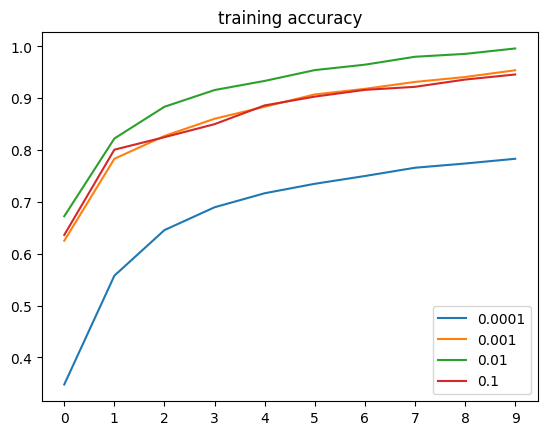

In [32]:

for lr, hist in lr_scores.items():
    plt.plot(hist['accuracy'],label=lr)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy')
plt.legend()

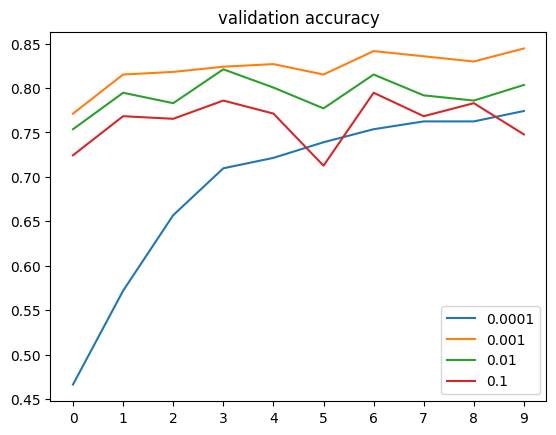

In [33]:
for lr, hist in lr_scores.items():
    #plt.plot(hist['accuracy'],label=lr)
    plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('validation accuracy')
plt.legend()

In [34]:
learning_rate=0.001

## Checkpointing

- Saving the best model only
- Traiing a model with callbacks

In [39]:
model.save_weights('model_v1.weights.h5')

In [43]:
epoch = 12
val_accuracy=0.824
f"xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5"

'xception_v1_12_0.824.h5'

In [44]:
checkpoint = keras.callbacks.ModelCheckpoint('xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only=True,
                                             monitor='val_accuracy',
                                             mode='max'
                                            )

In [45]:
learning_rate = 0.01

model = make_model(learning_rate=learning_rate)

history = model.fit(train_ds,epochs=10,
                    validation_data=val_ds,
                    callbacks=[checkpoint])



Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.5555 - loss: 1.9710

96/96 ━━━━━━━━━━━━━━━━━━━━ 63s 641ms/step - accuracy: 0.6519 - loss: 1.3544 - val_accuracy: 0.7771 - val_loss: 0.8645
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.8215 - loss: 0.5715

96/96 ━━━━━━━━━━━━━━━━━━━━ 77s 804ms/step - accuracy: 0.8175 - loss: 0.5782 - val_accuracy: 0.7889 - val_loss: 0.8970
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 859ms/step - accuracy: 0.8814 - loss: 0.3445 - val_accuracy: 0.7683 - val_loss: 0.9616
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9155 - loss: 0.2380

96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 794ms/step - accuracy: 0.9140 - loss: 0.2436 - val_accuracy: 0.8065 - val_loss: 0.8407
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9349 - loss: 0.1715

96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9316 - loss: 0.1842 - val_accuracy: 0.8094 - val_loss: 0.8176
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.9641 - loss: 0.1015

96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 933ms/step - accuracy: 0.9612 - loss: 0.1037 - val_accuracy: 0.8123 - val_loss: 0.8605
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 83s 866ms/step - accuracy: 0.9743 - loss: 0.0806 - val_accuracy: 0.7977 - val_loss: 1.0581
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9756 - loss: 0.0856

96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 847ms/step - accuracy: 0.9778 - loss: 0.0812 - val_accuracy: 0.8240 - val_loss: 0.8849
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 86s 894ms/step - accuracy: 0.9896 - loss: 0.0473 - val_accuracy: 0.8094 - val_loss: 0.8514
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 916ms/step - accuracy: 0.9785 - loss: 0.0617 - val_accuracy: 0.8182 - val_loss: 0.9183
